# Illuminants

Exploration of the CIE illuminant dataset covering all standard families: D-series (daylight), F-series (fluorescent), LED-series, and Illuminant A.

## Contents

1. **Setup** – imports and data loading
2. **Spectral Power Distributions** – raw SPDs on a shared y-scale
3. **Normalisation** – L1 (total power) and L2 (unit vector) normalisation with side-by-side comparison
4. **Cosine Similarity** – pairwise similarity heatmap across all illuminants
5. **Clustering** – k-means and agglomerative hierarchical clustering on L2-normalised SPDs
6. **PCA Visualisation** – 2D and 3D scatter of illuminants in PCA space, coloured by cluster
7. **Chosen Illuminants** – k-means cluster representatives (closest to each centroid), visualised on PCA and similarity heatmap
8. **PCA and NMF Basis Components** – comparison of learned basis functions on the full vs chosen illuminant set
9. **CIE 1931 xy Chromaticity Diagrams** – per-family chromaticity plots with Planckian locus overlay
10. **Train / Test Split** – chromaticity diagram coloured by train/test membership

In [33]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from sklearn.cluster import k_means
from sklearn.decomposition import PCA, NMF
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
import colour
from colour.temperature import CCT_to_xy_CIE_D

from illuminants import load_illuminants, ILL_CATEGORIES, ILL_TEST_SET, spd_to_xy
from visualization.plot_spectrum import plot_spectrum

# Global plot style
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 2.0,
})

ALL_FAMILIES = ("daylight", "fluorescent", "A", "led")

wavelengths, illuminants_raw = load_illuminants(normalize=False, include=ALL_FAMILIES)
print(f"Loaded {len(illuminants_raw)} illuminants: {list(illuminants_raw.keys())}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 28 illuminants: ['D50', 'D55', 'D60', 'D65', 'D75', 'D93', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'A', 'LED-B1', 'LED-B2', 'LED-B3', 'LED-B4', 'LED-B5', 'LED-BH1', 'LED-RGB1', 'LED-V1', 'LED-V2']


## Spectral Power Distributions

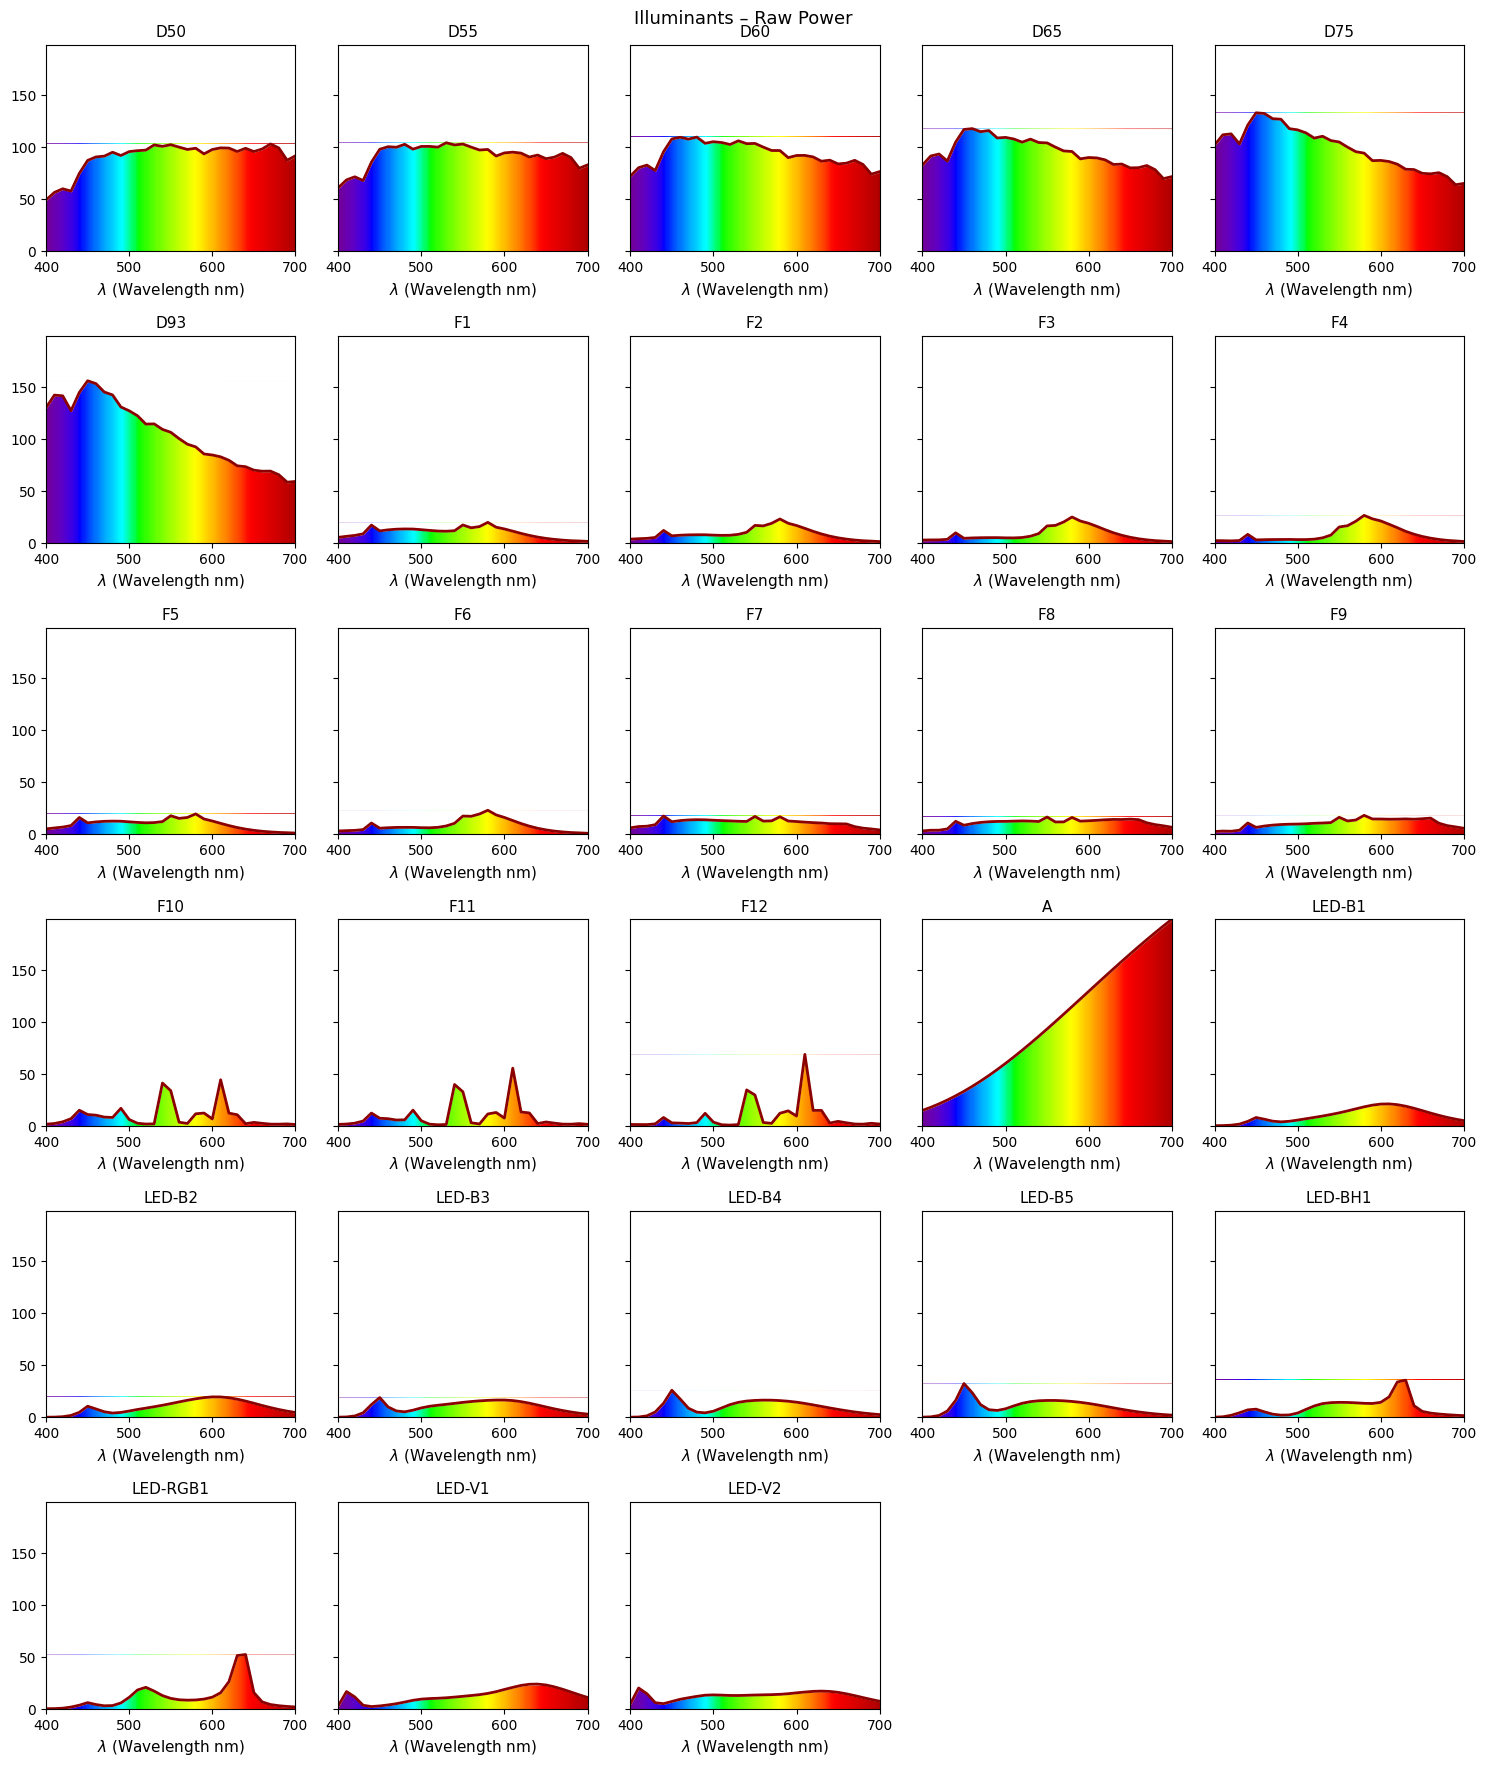

In [34]:
def plot_illuminant_grid(illum_dict, wavelengths, title, max_per_row=5):
    """Plot all illuminants in a shared-y grid."""
    n = len(illum_dict)
    n_rows = (n + max_per_row - 1) // max_per_row
    fig, axes = plt.subplots(n_rows, max_per_row, figsize=(15, 3 * n_rows),
                              squeeze=False, sharey=True)
    fig.suptitle(title, fontsize=13)
    for i, (name, spd) in enumerate(illum_dict.items()):
        ax = axes[i // max_per_row][i % max_per_row]
        fig.sca(ax)
        plot_spectrum(wavelengths, spd)
        ax.set_title(name)
    for j in range(i + 1, n_rows * max_per_row):
        axes[j // max_per_row][j % max_per_row].axis("off")
    plt.tight_layout()
    plt.show()

plot_illuminant_grid(illuminants_raw, wavelengths, "Illuminants – Raw Power")

## Normalisation

The raw illuminants have very different absolute power levels, making direct
comparison of spectral shape difficult.  Two normalisation strategies are compared:

- **L1 (total power)** – each SPD sums to 1; preserves relative spectral shape.
- **L2 (unit vector)** – each SPD has unit Euclidean norm; natural for cosine-similarity analysis.

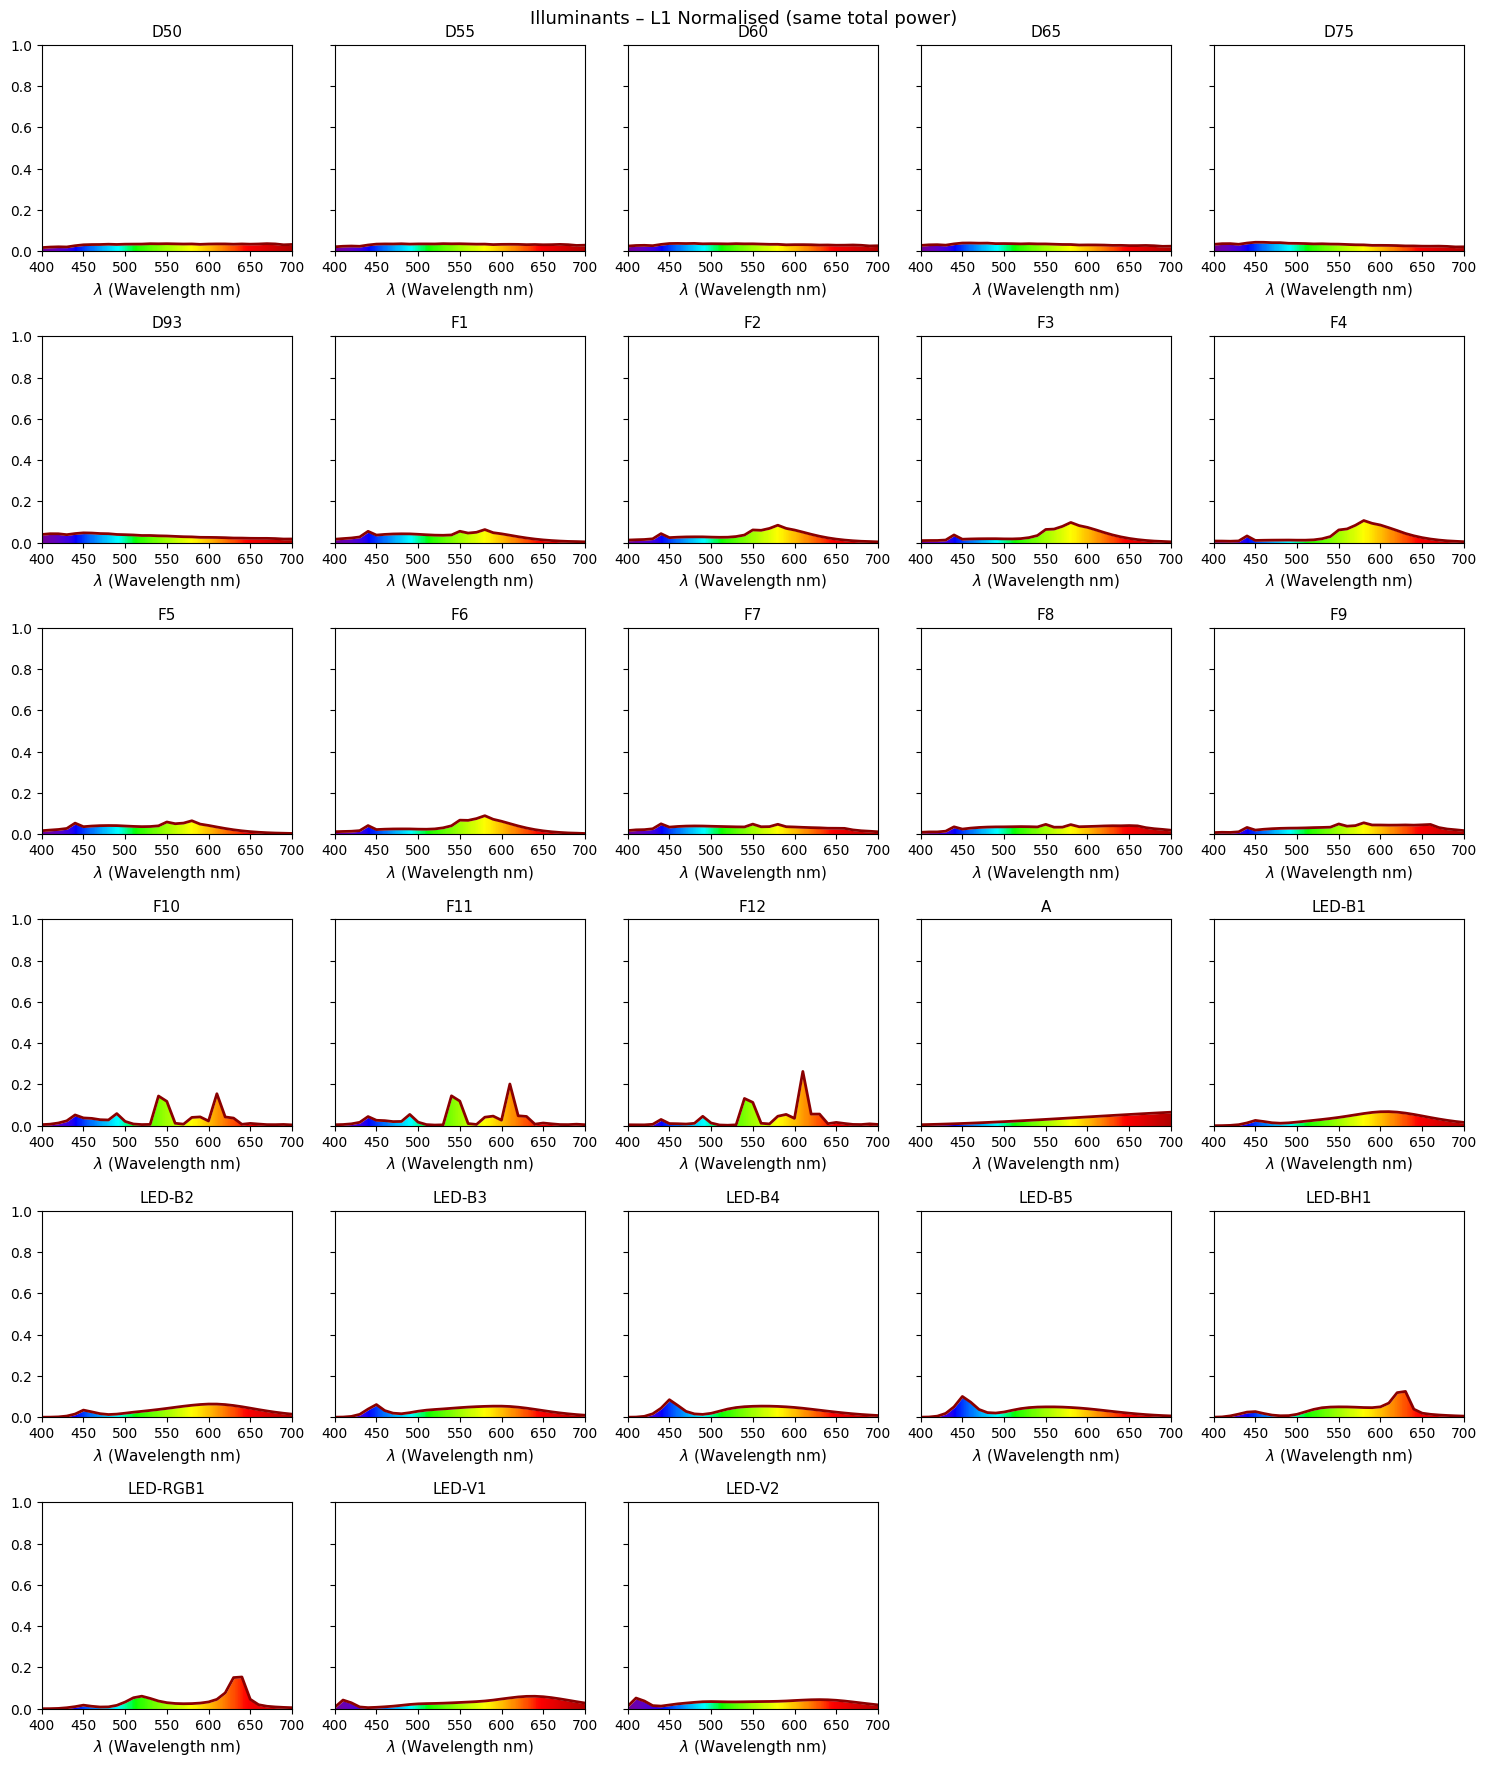

In [35]:
def l1_normalize(illum_dict):
    return {name: spd / spd.sum() for name, spd in illum_dict.items()}

def l2_normalize(illum_dict):
    return {name: spd / np.linalg.norm(spd) for name, spd in illum_dict.items()}

illuminants_l1 = l1_normalize(illuminants_raw)
illuminants_l2 = l2_normalize(illuminants_raw)

plot_illuminant_grid(illuminants_l1, wavelengths, "Illuminants – L1 Normalised (same total power)")

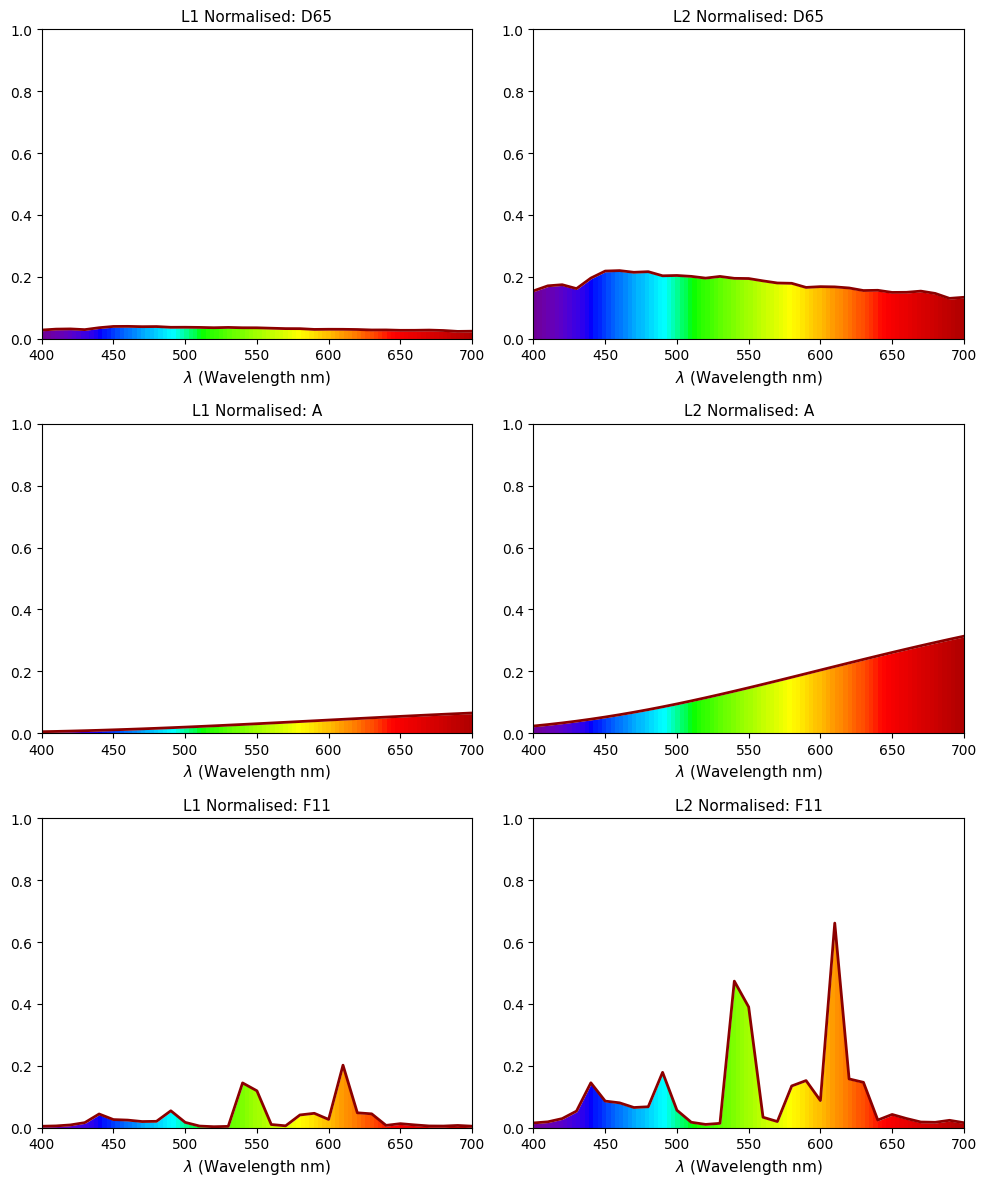

In [36]:
examples = ["D65", "A", "F11"]
fig, axes = plt.subplots(len(examples), 2, figsize=(10, 4 * len(examples)), squeeze=False)
for i, name in enumerate(examples):
    for j, (norm_label, illum_dict) in enumerate([("L1", illuminants_l1), ("L2", illuminants_l2)]):
        ax = axes[i][j]
        fig.sca(ax)
        plot_spectrum(wavelengths, illum_dict[name])
        ax.set_title(f"{norm_label} Normalised: {name}")
plt.tight_layout()
plt.show()

## Cosine Similarity

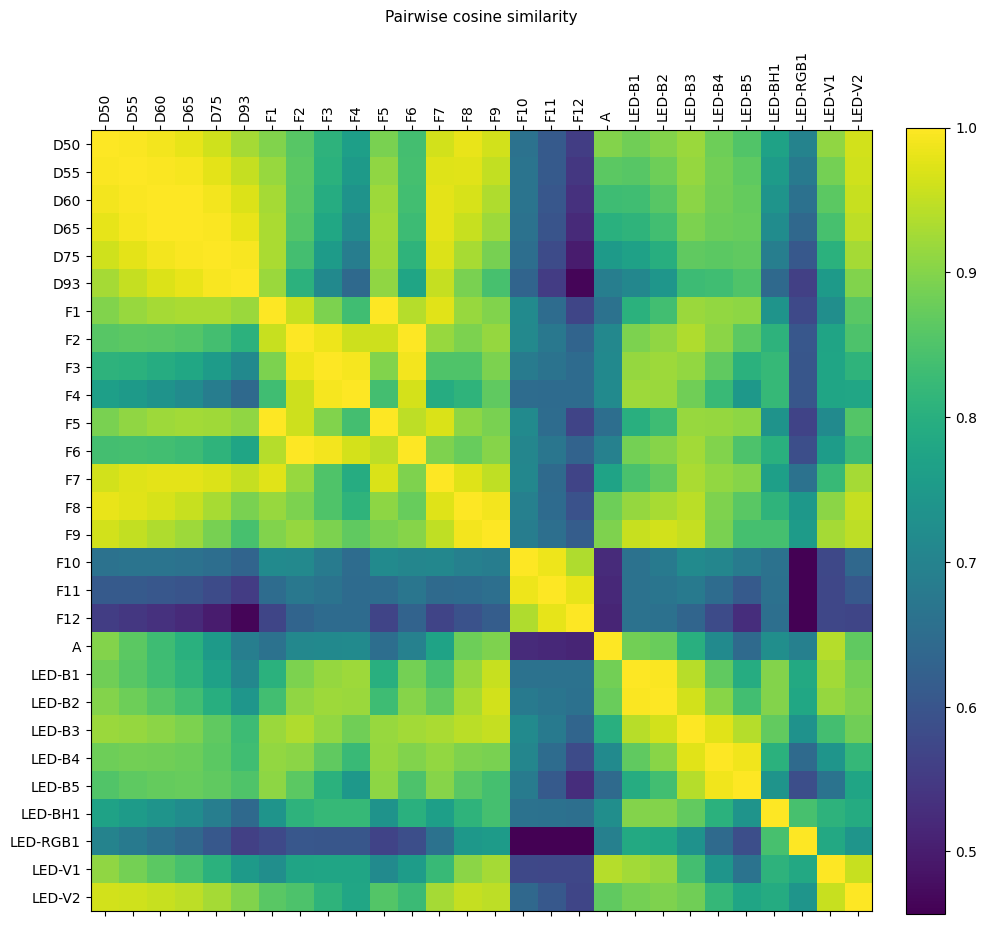

Mean pairwise cosine similarity (off-diagonal): 0.8078


In [37]:
# Use L2-normalised SPDs so the dot product equals cosine similarity directly
X_all = np.stack(list(illuminants_l2.values()))  # (N, 31)
names_all = list(illuminants_l2.keys())

cos_sim = X_all @ X_all.T  # equivalent to pairwise cosine similarity

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.matshow(cos_sim)
ax.set_xticks(range(len(names_all)), names_all, rotation=90)
ax.set_yticks(range(len(names_all)), names_all)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Pairwise cosine similarity", pad=20)
plt.tight_layout()
plt.show()

off_diag = cos_sim[np.triu_indices(len(names_all), k=1)]
print(f"Mean pairwise cosine similarity (off-diagonal): {off_diag.mean():.4f}")

## Clustering

K-means and agglomerative hierarchical clustering on L2-normalised SPDs.
Cosine distance is equivalent to Euclidean distance after L2-normalisation.

In [38]:
N_CLUSTERS = 10
SEED = 42

kmeans_centroids, kmeans_labels, _ = k_means(X_all, n_clusters=N_CLUSTERS, random_state=SEED)

D = pdist(X_all, metric="euclidean")
Z = linkage(D, method="average")
hierarchical_labels = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")

## PCA Visualisation

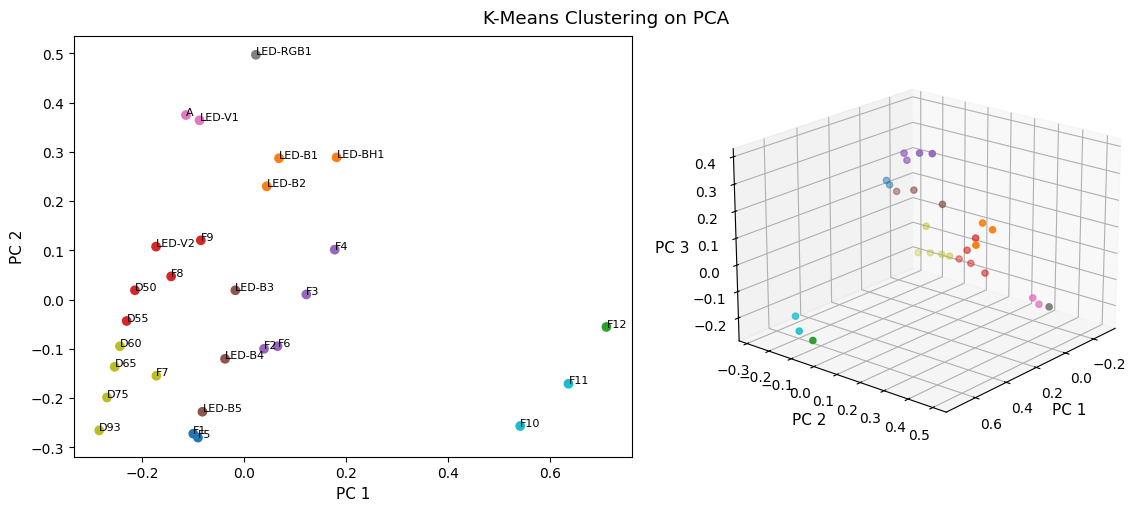

In [39]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_all)

def plot_pca_scatter(X_pca, labels, title, names=None, cmap="tab10"):
    fig = plt.figure(figsize=(12, 5), layout="constrained")
    fig.suptitle(title)

    ax2d = fig.add_subplot(121)
    ax2d.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap=cmap)
    ax2d.set_xlabel("PC 1")
    ax2d.set_ylabel("PC 2")
    if names is not None:
        for idx, name in enumerate(names):
            ax2d.annotate(name, (X_pca[idx, 0], X_pca[idx, 1]), fontsize=8)

    ax3d = fig.add_subplot(122, projection="3d")
    ax3d.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap=cmap)
    ax3d.set_xlabel("PC 1"); ax3d.set_ylabel("PC 2"); ax3d.set_zlabel("PC 3", labelpad=5)
    ax3d.view_init(elev=20, azim=40)
    plt.show()

plot_pca_scatter(X_pca, kmeans_labels, "K-Means Clustering on PCA", names_all)

## Chosen Illuminants (K-Means Representatives)

For each k-means cluster, select the illuminant closest to the cluster centroid.

Chosen illuminants: ['A', 'D50', 'D65', 'F10', 'F12', 'F3', 'F5', 'LED-B1', 'LED-B4', 'LED-RGB1']


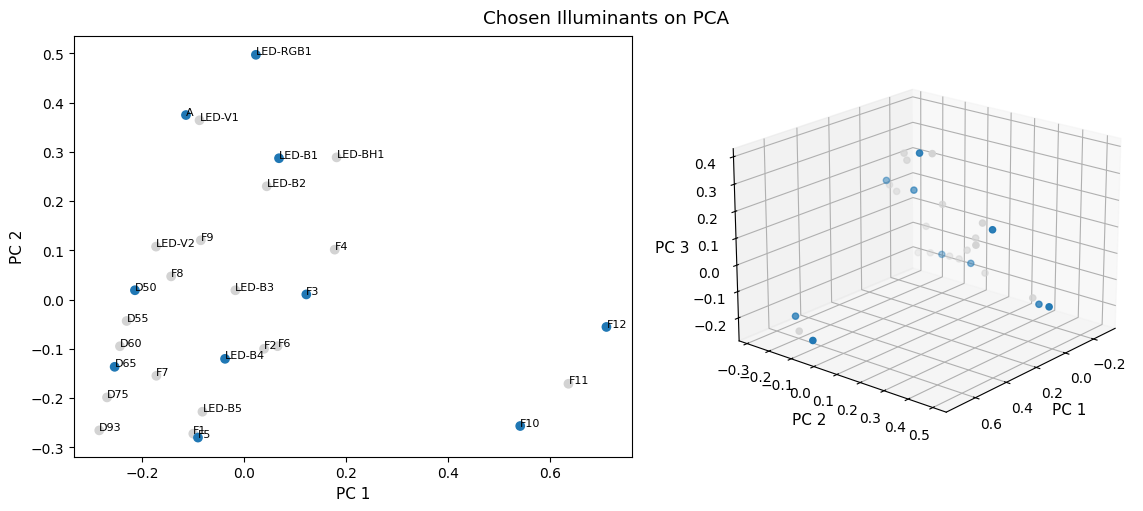

In [40]:
clusters = {i: [] for i in range(N_CLUSTERS)}
for idx, label in enumerate(kmeans_labels):
    clusters[label].append(idx)

chosen_idxs = []
for cluster_id, members in clusters.items():
    centroid = kmeans_centroids[cluster_id]
    chosen = min(members, key=lambda p: np.linalg.norm(X_all[p] - centroid))
    chosen_idxs.append(chosen)

chosen_names = [names_all[i] for i in chosen_idxs]
print("Chosen illuminants:", sorted(chosen_names))

chosen_map = [1 if i in chosen_idxs else 0 for i in range(len(names_all))]
cmap_chosen = mpl.colors.ListedColormap(["lightgray", "tab:blue"])
plot_pca_scatter(X_pca, chosen_map, "Chosen Illuminants on PCA", names_all, cmap=cmap_chosen)

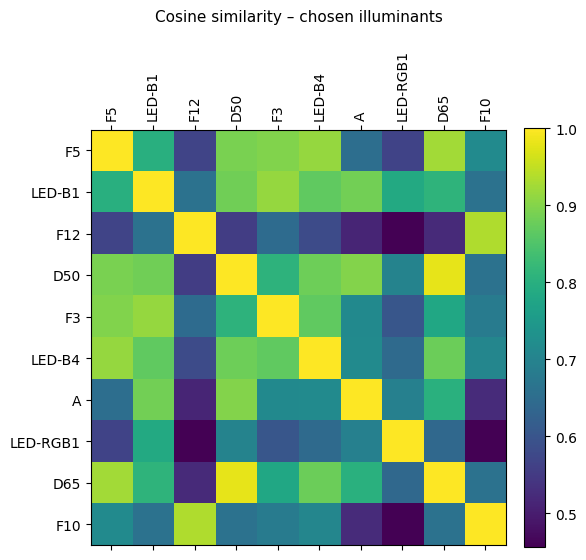

Mean pairwise cosine similarity (chosen set): 0.7315


In [41]:
chosen_illums = {name: illuminants_l2[name] for name in chosen_names}
X_chosen = np.stack(list(chosen_illums.values()))
cos_sim_chosen = X_chosen @ X_chosen.T

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.matshow(cos_sim_chosen)
ax.set_xticks(range(len(chosen_names)), list(chosen_illums.keys()), rotation=90)
ax.set_yticks(range(len(chosen_names)), list(chosen_illums.keys()))
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Cosine similarity – chosen illuminants", pad=20)
plt.tight_layout()
plt.show()

off_diag_chosen = cos_sim_chosen[np.triu_indices(len(chosen_names), k=1)]
print(f"Mean pairwise cosine similarity (chosen set): {off_diag_chosen.mean():.4f}")

## PCA and NMF Basis Components

Compare the learned basis functions on the full illuminant set vs the chosen subset.

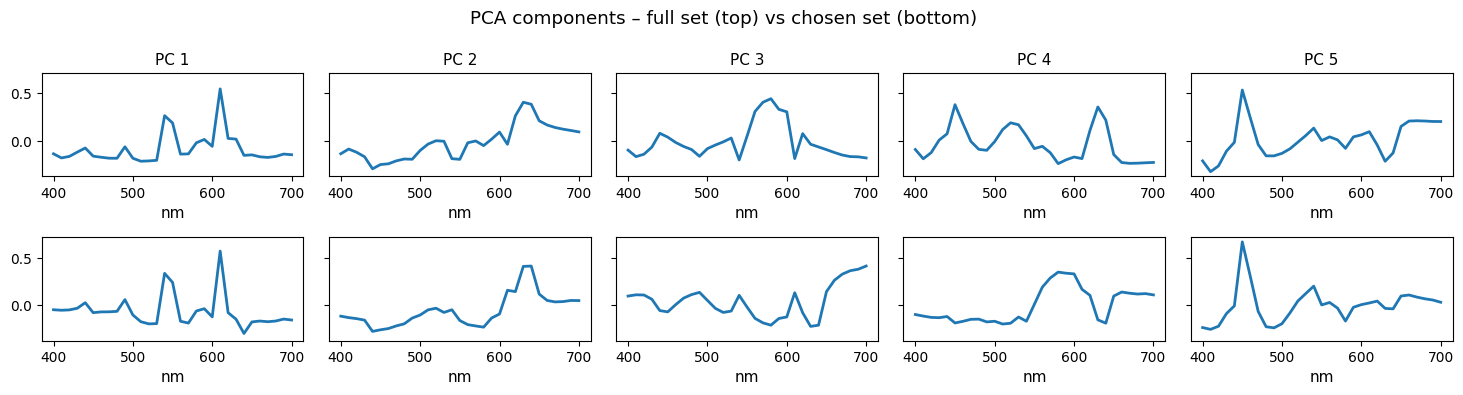

In [42]:
pca_chosen = PCA(n_components=10).fit(X_chosen)

N_SHOW = 5
fig, axs = plt.subplots(2, N_SHOW, figsize=(3 * N_SHOW, 4), sharey=True)
fig.suptitle("PCA components – full set (top) vs chosen set (bottom)")
for i in range(N_SHOW):
    axs[0, i].plot(wavelengths, pca.components_[i])
    axs[0, i].set_title(f"PC {i+1}")
    axs[1, i].plot(wavelengths, pca_chosen.components_[i])
    axs[0, i].set_xlabel("nm"); axs[1, i].set_xlabel("nm")
plt.tight_layout()
plt.show()

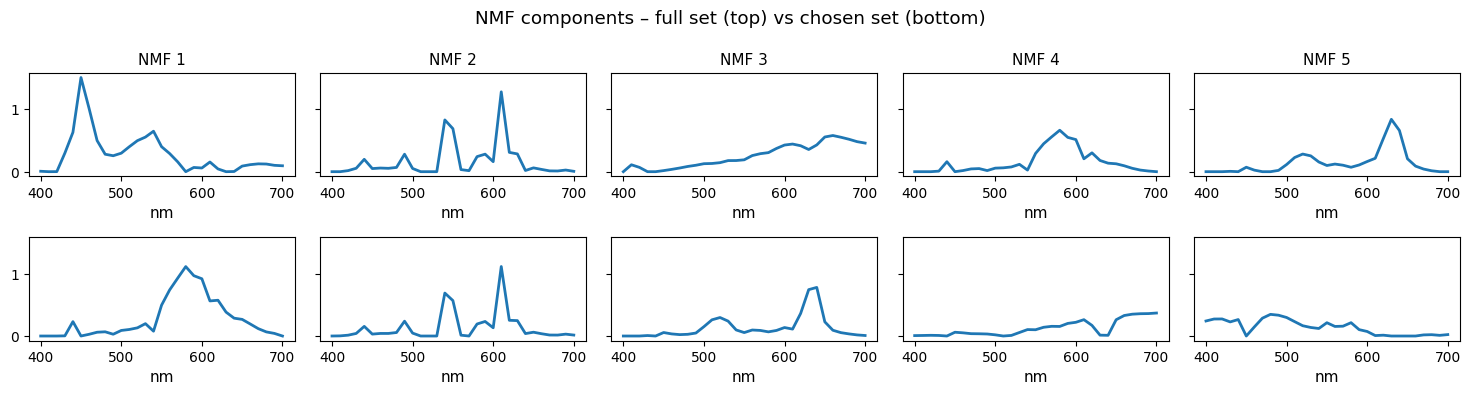

In [43]:
nmf       = NMF(n_components=6, max_iter=800).fit(X_all)
nmf_chosen = NMF(n_components=6, max_iter=800).fit(X_chosen)

fig, axs = plt.subplots(2, N_SHOW, figsize=(3 * N_SHOW, 4), sharey=True)
fig.suptitle("NMF components – full set (top) vs chosen set (bottom)")
for i in range(N_SHOW):
    axs[0, i].plot(wavelengths, nmf.components_[i])
    axs[0, i].set_title(f"NMF {i+1}")
    axs[1, i].plot(wavelengths, nmf_chosen.components_[i])
    axs[0, i].set_xlabel("nm"); axs[1, i].set_xlabel("nm")
plt.tight_layout()
plt.show()

## CIE 1931 xy Chromaticity Diagrams

In [44]:
def draw_planckian_locus(ax=None, show_isotherms=False, locus_kwargs=None, isotherm_kwargs=None):
    """Overlay the Planckian locus (and optionally isotherms) on *ax*."""
    if ax is None:
        ax = plt.gca()
    locus_kwargs    = locus_kwargs    or dict(color="gray", linewidth=1.0, label="Planckian locus")
    isotherm_kwargs = isotherm_kwargs or dict(color="gray", linewidth=0.5)

    locus_lines, iso_lines = colour.plotting.lines_planckian_locus(
        labels=[], mireds=False, iso_temperature_lines_D_uv=0.05)

    pts = np.stack([r["position"] for r in locus_lines])
    ax.plot(pts[:, 0], pts[:, 1], **locus_kwargs)

    if show_isotherms:
        for rec in iso_lines:
            p, n = rec["position"], rec["normal"]
            ax.plot([p[0]-n[0], p[0]+n[0]], [p[1]-n[1], p[1]+n[1]], **isotherm_kwargs)
    return ax

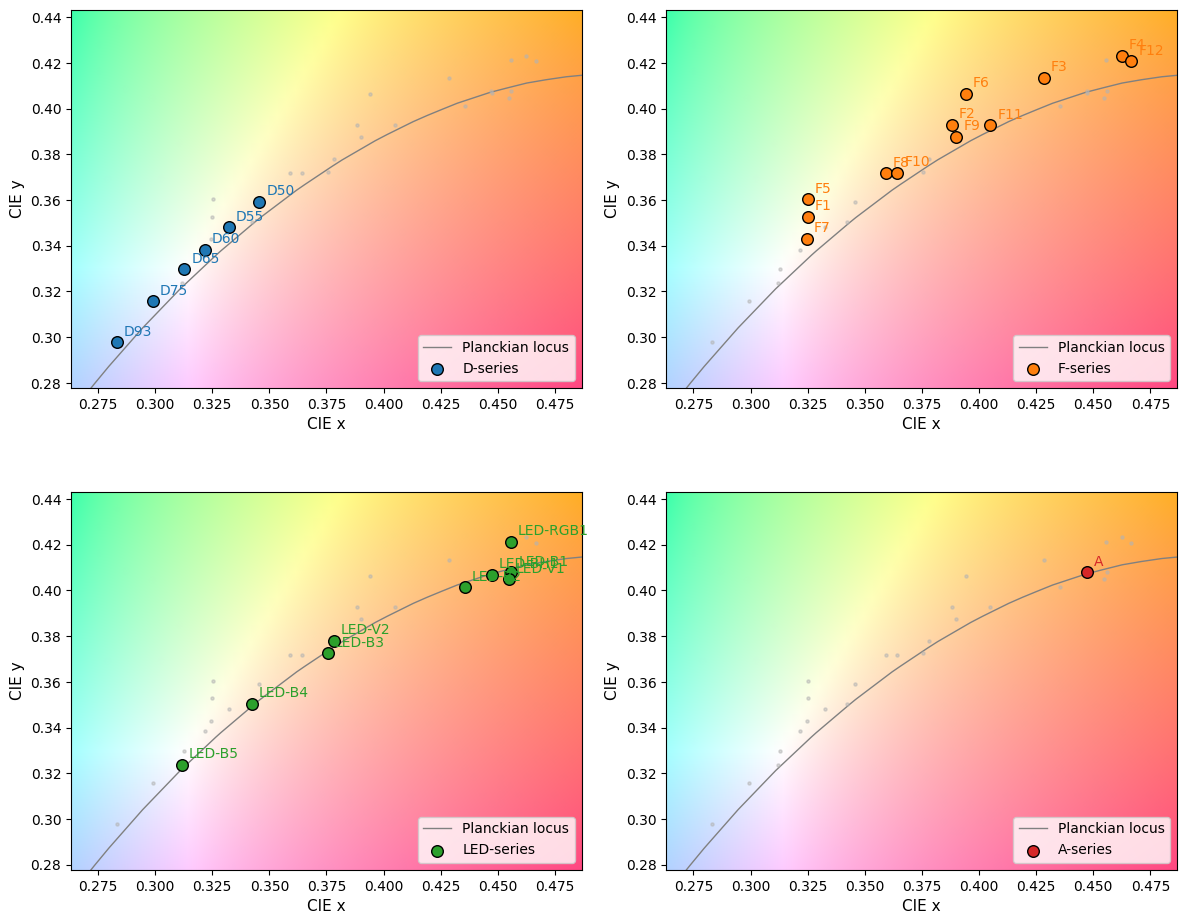

In [45]:
def plot_xy_by_category(category_prefix, ax=None, color="tab:blue"):
    """
    Plot illuminants whose name starts with *category_prefix* on the CIE 1931
    chromaticity diagram.  All other illuminants are shown as small grey points
    for spatial context.
    """
    wavelengths, illum_dict = load_illuminants(normalize=True, include=ALL_FAMILIES)
    xy = {name: spd_to_xy(spd, wavelengths) for name, spd in illum_dict.items()}

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    colour.plotting.plot_chromaticity_diagram_CIE1931(show=False, axes=ax)
    draw_planckian_locus(ax)

    all_xs, all_ys = [], []
    used_label = False
    for name, (x, y) in xy.items():
        if np.isnan(x) or np.isnan(y):
            continue
        all_xs.append(x); all_ys.append(y)
        if name.startswith(category_prefix):
            label = f"{category_prefix}-series" if not used_label else None
            used_label = True
            ax.scatter(x, y, marker="o", color=color, edgecolor="k", s=70, zorder=10, label=label)
            ax.text(x + 0.003, y + 0.003, name, fontsize=10, color=color, zorder=11)
        else:
            ax.scatter(x, y, marker=".", color="0.7", s=20, alpha=0.5, zorder=5)

    margin = 0.02
    ax.set_xlim(min(all_xs) - margin, max(all_xs) + margin)
    ax.set_ylim(min(all_ys) - margin, max(all_ys) + margin)
    ax.set_title("")
    ax.legend(loc="lower right")
    ax.set_xlabel("CIE x"); ax.set_ylabel("CIE y")
    return ax


fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, (prefix, color) in zip(axes.flatten(),
                                [("D",   "tab:blue"),
                                 ("F",   "tab:orange"),
                                 ("LED", "tab:green"),
                                 ("A",   "tab:red")]):
    plot_xy_by_category(prefix, ax=ax, color=color)
plt.tight_layout()
plt.show()

## Train / Test Split on Chromaticity Diagram

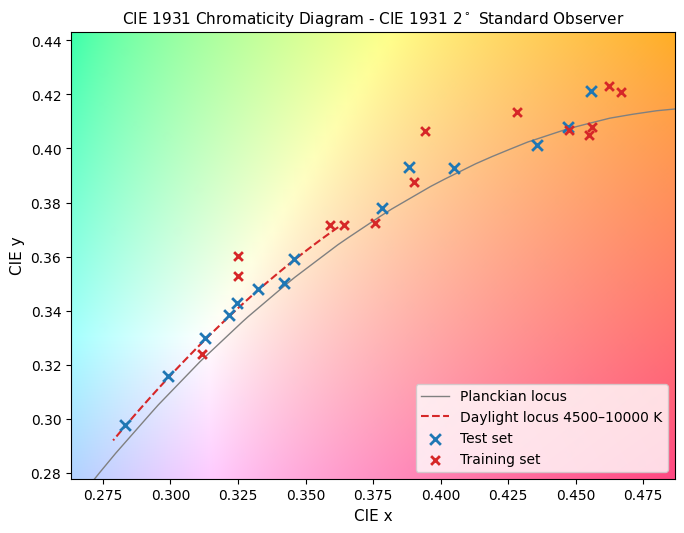

In [46]:
def plot_xy_train_test(ax=None):
    wavelengths, illum_dict = load_illuminants(normalize=True, include=ALL_FAMILIES)
    xy = {name: spd_to_xy(spd, wavelengths) for name, spd in illum_dict.items()}

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))

    colour.plotting.plot_chromaticity_diagram_CIE1931(show=False, axes=ax)
    draw_planckian_locus(ax)

    # Daylight locus overlay
    temps = np.linspace(4500, 10000, 80)
    xy_day = CCT_to_xy_CIE_D(temps)
    ax.plot(xy_day[:, 0], xy_day[:, 1], color="tab:red", linestyle="--",
            linewidth=1.5, label="Daylight locus 4500–10000 K", zorder=9)

    xs, ys = [], []
    used = {"test": False, "train": False}
    for name, (x, y) in xy.items():
        if np.isnan(x) or np.isnan(y):
            continue
        xs.append(x); ys.append(y)
        in_test = name in ILL_TEST_SET
        color  = "tab:blue" if in_test else "tab:red"
        key    = "test" if in_test else "train"
        label  = ("Test set" if in_test else "Training set") if not used[key] else None
        used[key] = True
        ax.scatter(x, y, marker="x", color=color, s=60 if in_test else 40,
                   zorder=10, label=label)

    margin = 0.02
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)
    ax.legend(loc="lower right")
    ax.grid(False)
    ax.set_xlabel("CIE x"); ax.set_ylabel("CIE y")
    return ax

plot_xy_train_test()
plt.show()